# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [ ]:
# imports the necessary libraries for data manipulation
import numpy as np
import pandas as pd

# imports the necessary libraries for data visualization
import matplotlib.pyplot as plt # (a low level plotting library) to be able to use seaborn
import seaborn as sns

sns.set()

# imports the necessary library for statistical analysis
from scipy import stats

# imports the ttest_ind function from the scipy library.
from scipy.stats import ttest_ind

# imports the proportions_ztest function from the statsmodels library.
from statsmodels.stats.proportion import proportions_ztest

# imports the chi2_contingency function from the scipy library.
from scipy.stats import chi2_contingency

# imports the f_oneway function from the scipy library.
from scipy.stats import f_oneway

# command to tell Python to actually display the graphs
%matplotlib inline

# importing plotly
import plotly.express as px

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)
# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression
# to build linear regression_model using statsmodels
import statsmodels.api as sm
# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
# to build model for prediction
import statsmodels.stats.api as sms
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to tune different models
from sklearn.model_selection import GridSearchCV

# to get different metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve)

# imports warnings module
import warnings
# ignores all warnings
warnings.filterwarnings("ignore")
# imports 'ConvergenceWarning' from the statsmodels library
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# ignores only the ConvergenceWarning from the statsmodels library.
warnings.simplefilter("ignore", ConvergenceWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python Course/Module 4/Project/INNHotelsGroup.csv')

In [ ]:
# A copy of the dataframe df was created to keep the original data intact.
df_copy = df.copy()

In [ ]:
# returns the first 5 rows in the dataset.
df_copy.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.680,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.500,0,Canceled


In [ ]:
# returns the last 5 rows in the dataset.
df_copy.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.800,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.950,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.390,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.500,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.670,0,Not_Canceled


## Data Overview

- Observations
- Sanity checks

In [ ]:
# checks the number of rows and columns in the data
df_copy.shape

(36275, 19)

In [ ]:
# checks the datatype of each column, the total rows and columns, and the memory usage.
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
# checks the statistical summary of the variables
df_copy.describe(include='all').T # all variables

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,36275,36275,INN36275,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_adults,36275.000,NaN,NaN,NaN,1.845,0.519,0.000,2.000,2.000,2.000,4.000
no_of_children,36275.000,NaN,NaN,NaN,0.105,0.403,0.000,0.000,0.000,0.000,10.000
no_of_weekend_nights,36275.000,NaN,NaN,NaN,0.811,0.871,0.000,0.000,1.000,2.000,7.000
no_of_week_nights,36275.000,NaN,NaN,NaN,2.204,1.411,0.000,1.000,2.000,3.000,17.000
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.000,NaN,NaN,NaN,0.031,0.173,0.000,0.000,0.000,0.000,1.000
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.000,NaN,NaN,NaN,85.233,85.931,0.000,17.000,57.000,126.000,443.000
arrival_year,36275.000,NaN,NaN,NaN,2017.820,0.384,2017.000,2018.000,2018.000,2018.000,2018.000


In [ ]:
# total number of missing values in each column
print(df_copy.isnull().sum())
# total number of missing values in the data by adding the number of missing values in each columns
print(df_copy.isnull().sum().sum())

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64
0


In [ ]:
# checks for duplicates in the data and sums them
df_copy.duplicated().sum()

np.int64(0)

### Observations:

* There are no missing values.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

### Defining functions to create visualizations

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labelled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Distribution of number of adults

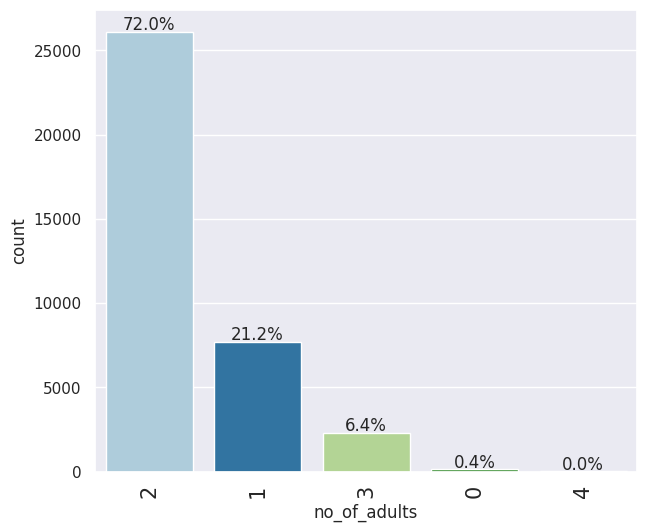

In [ ]:
# this code creates a labelled barplot of the distribution of the number of adults
labelled_barplot(df_copy, 'no_of_adults', perc=True)

#### Distribution of number of children


In [ ]:
# this code returns the frequncy of unique values and percentages for the number of children column
df_copy['no_of_children'].value_counts(normalize=True)

,proportion
no_of_children,
0,0.926
1,0.045
2,0.029
3,0.001
9,0.000
10,0.000


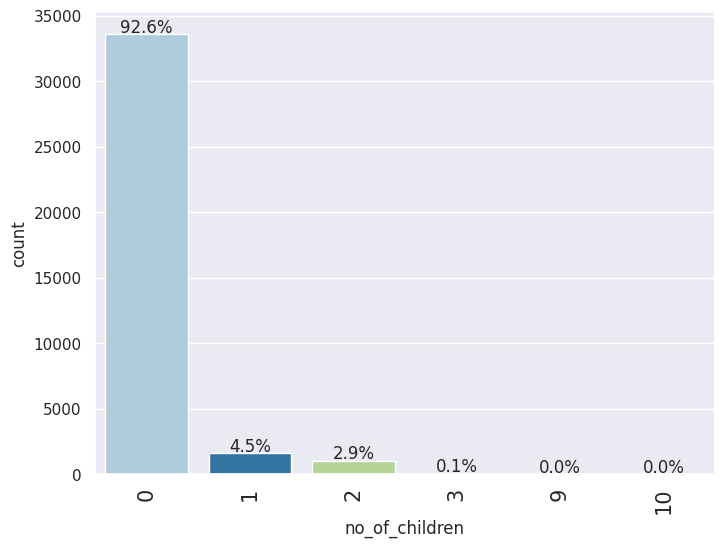

In [ ]:
# this code creates a labelled barplot of the distribution of the number of children
labelled_barplot(df_copy, 'no_of_children', perc=True)

In [ ]:
# this code replaces values of 9 and 10 with the value 3 in the number of children column
df["no_of_children"] = df["no_of_children"].replace([9, 10], 3)

#### Distribution of number of weekend nights


In [ ]:
## this code returns the frequncy of unique values and percentages for the number of weekend nights
df_copy['no_of_weekend_nights'].value_counts(normalize=True)

,proportion
no_of_weekend_nights,
0,0.465
1,0.276
2,0.250
3,0.004
4,0.004
5,0.001
6,0.001
7,0.000


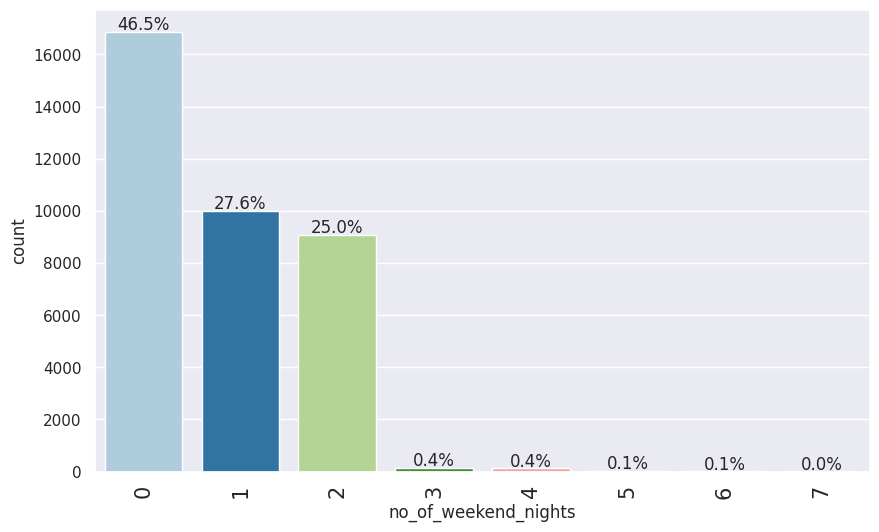

In [ ]:
# this code creates a labelled barplot of the distribution of the number of weekend nights
labelled_barplot(df_copy, 'no_of_weekend_nights', perc=True)

#### Distribution of number of week nights


In [ ]:
# this code returns the frequncy of unique values and percentages for the number of week nights
df_copy['no_of_week_nights'].value_counts(normalize=True)

,proportion
no_of_week_nights,
2,0.315
1,0.262
3,0.216
4,0.082
0,0.066
5,0.044
6,0.005
7,0.003
10,0.002


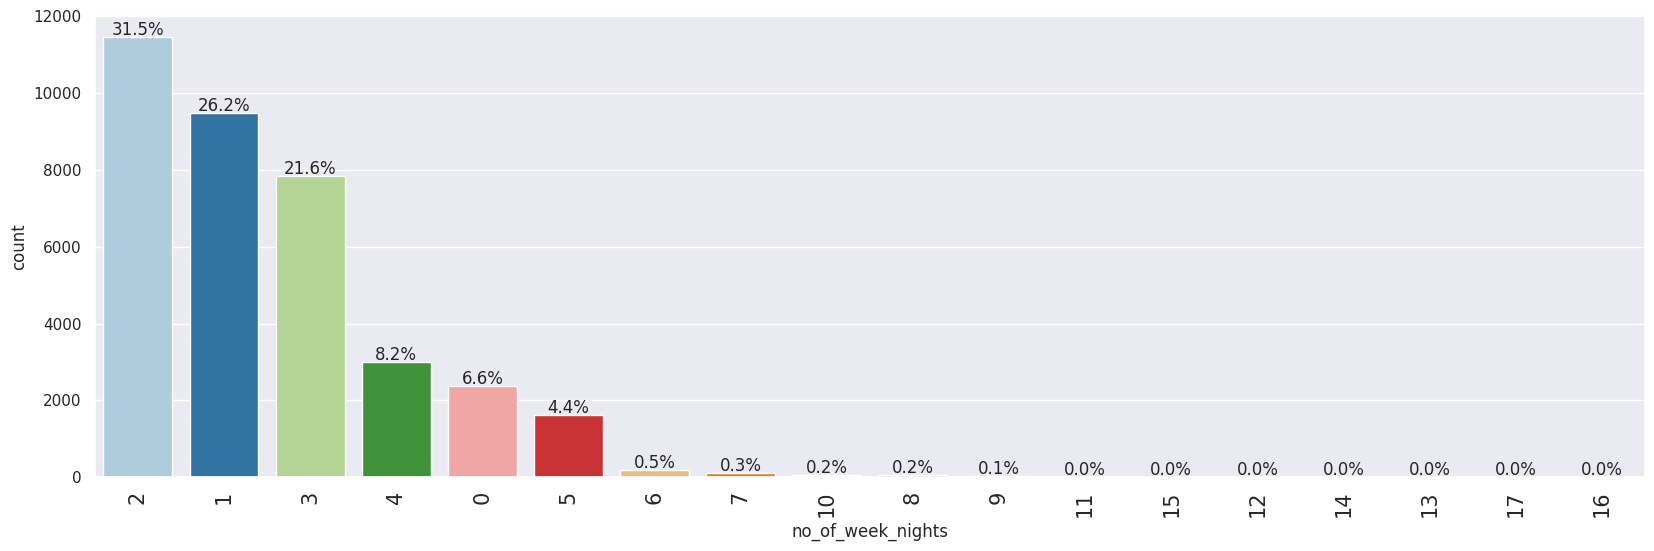

In [ ]:
# this code creates a labelled barplot of the distribution of the number of week nights
labelled_barplot(df_copy, 'no_of_week_nights', perc=True)

#### Distribution of type of meal plan


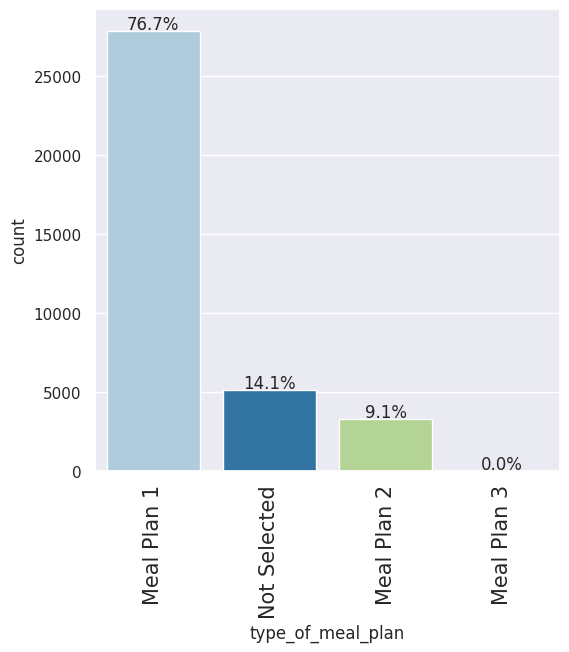

In [ ]:
# this code creates a labelled barplot of the distribution of the type of meal plan
labelled_barplot(df_copy, 'type_of_meal_plan', perc=True)

#### Distribution of required car parking space


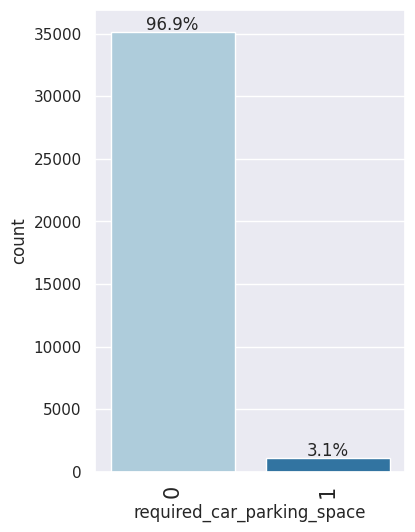

In [ ]:
# this code creates a labelled barplot of the distribution of required car parking space
labelled_barplot(df_copy, 'required_car_parking_space', perc=True)

#### Distribution of the type of reserved rooms

In [ ]:
# this code returns the frequency of unique values and percentages of the room type reserved column
df_copy['room_type_reserved'].value_counts(normalize=True)

,proportion
room_type_reserved,
Room_Type 1,0.775
Room_Type 4,0.167
Room_Type 6,0.027
Room_Type 2,0.019
Room_Type 5,0.007
Room_Type 7,0.004
Room_Type 3,0.000


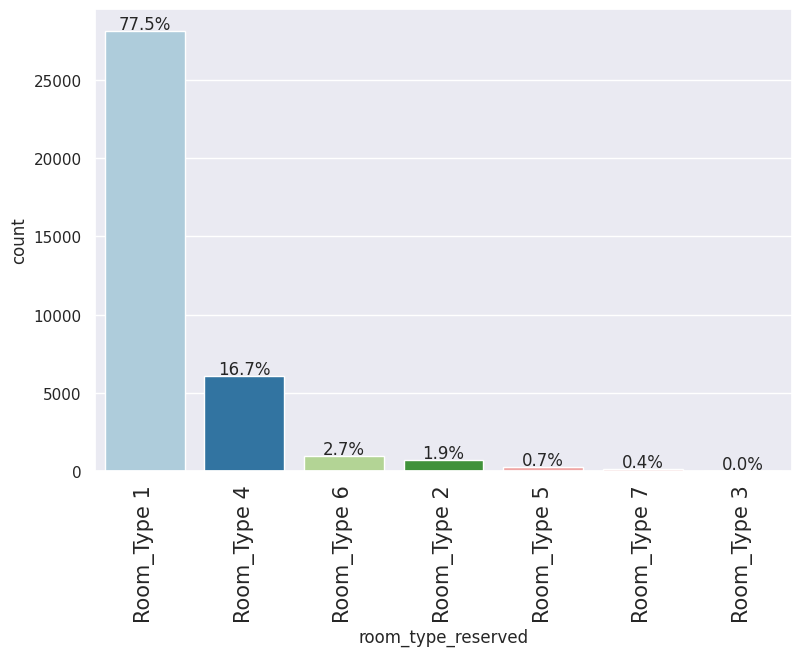

In [ ]:
# this code creates a labelled barplot of the distribution of the room type reserved
labelled_barplot(df_copy, 'room_type_reserved', perc=True)

#### Distribution of the lead time


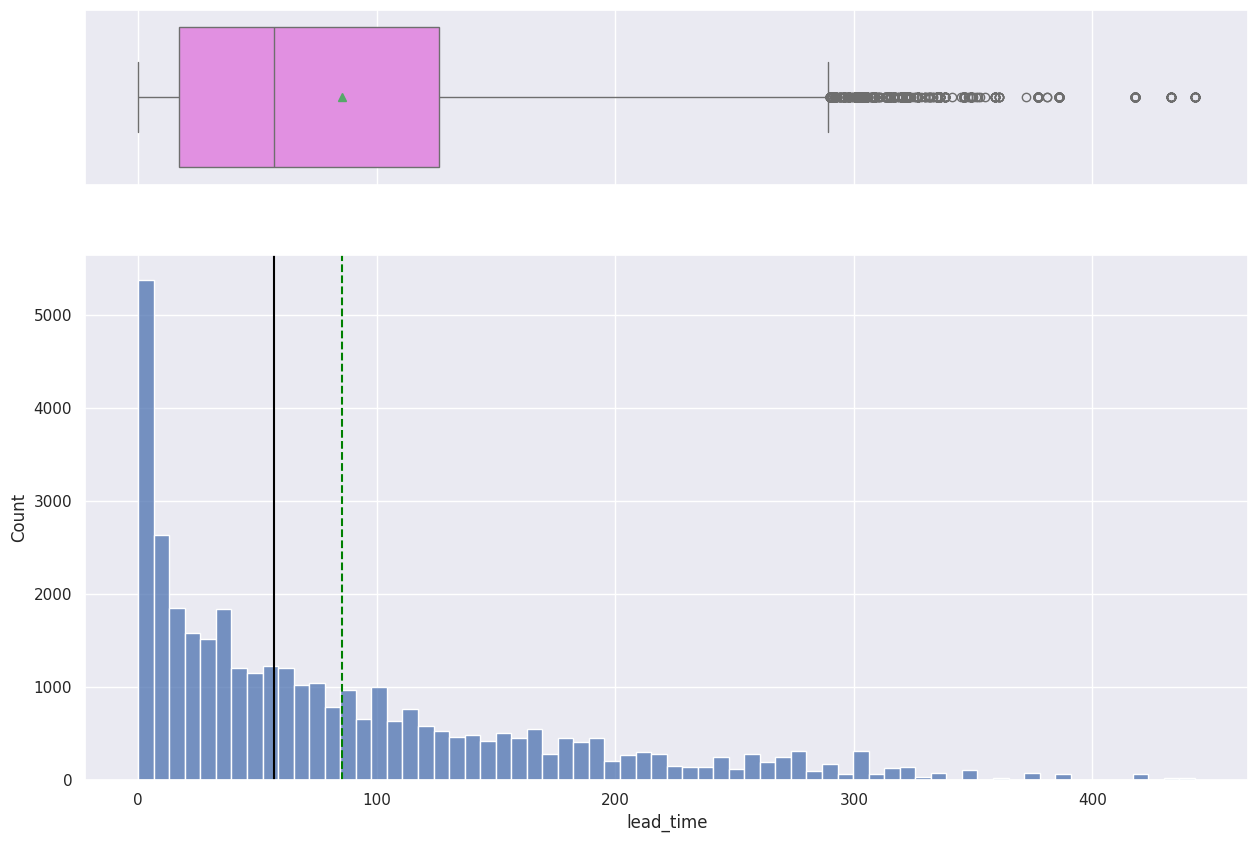

In [ ]:
# this code creates a histogram and boxplot of the distribution of lead time
histogram_boxplot(df_copy, 'lead_time')

#### Distribution of the arrival year


In [ ]:
# this code returns the frequency of unique values and percentages of the arrival year column
df_copy['arrival_year'].value_counts(normalize=True)

,proportion
arrival_year,
2018,0.820
2017,0.180


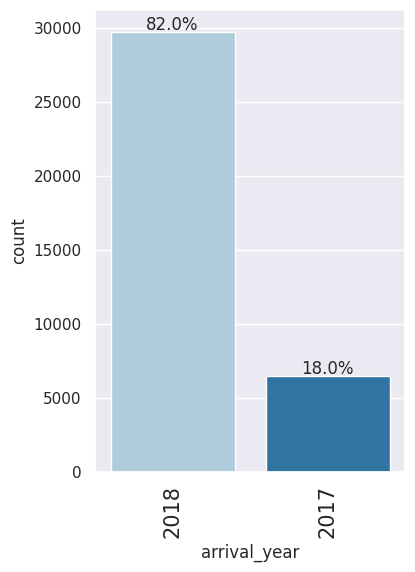

In [ ]:
# this code creates a labelled barplot of the distribution of the arrival year
labelled_barplot(df_copy, 'arrival_year', perc=True)

#### Distribution of the arrival month


In [ ]:
# this code returns the frequency of unique values and percentages of the arrival month column
df_copy['arrival_month'].value_counts(normalize=True)

,proportion
arrival_month,
10,0.147
9,0.127
8,0.105
6,0.088
12,0.083
11,0.082
7,0.080
4,0.075
5,0.072


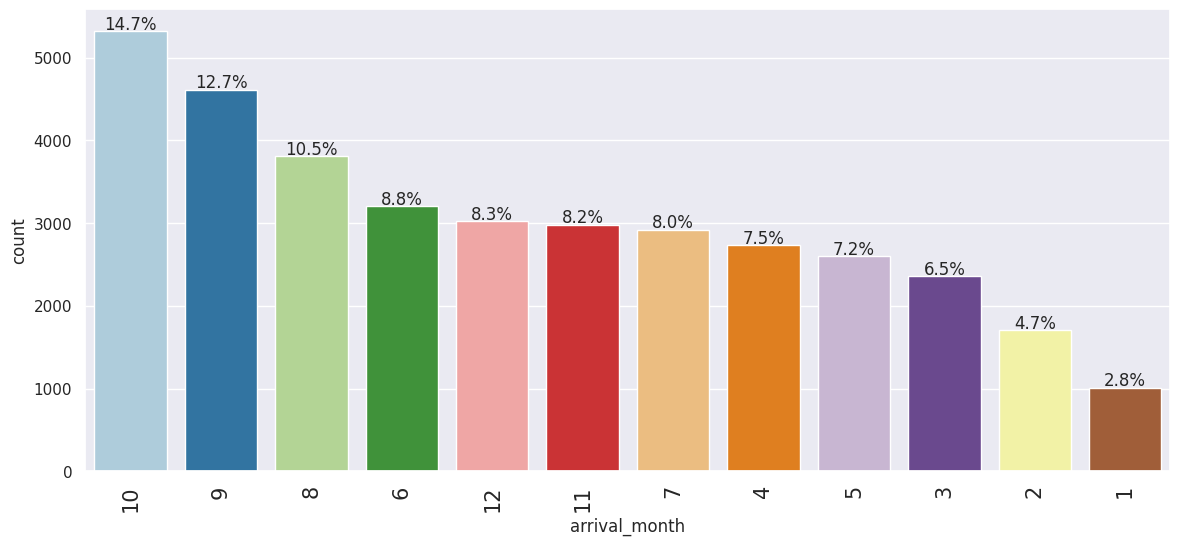

In [ ]:
# this code creates a labelled barplot of the distribution of the arrival month
labelled_barplot(df_copy, 'arrival_month', perc=True)

#### Arrival date


In [ ]:
# this code returns the frequency of unique values and percentages of the arrival date column
df_copy['arrival_date'].value_counts(normalize=True)

,proportion
arrival_date,
13,0.037
17,0.037
2,0.037
19,0.037
4,0.037
16,0.036
20,0.035
6,0.035
15,0.035


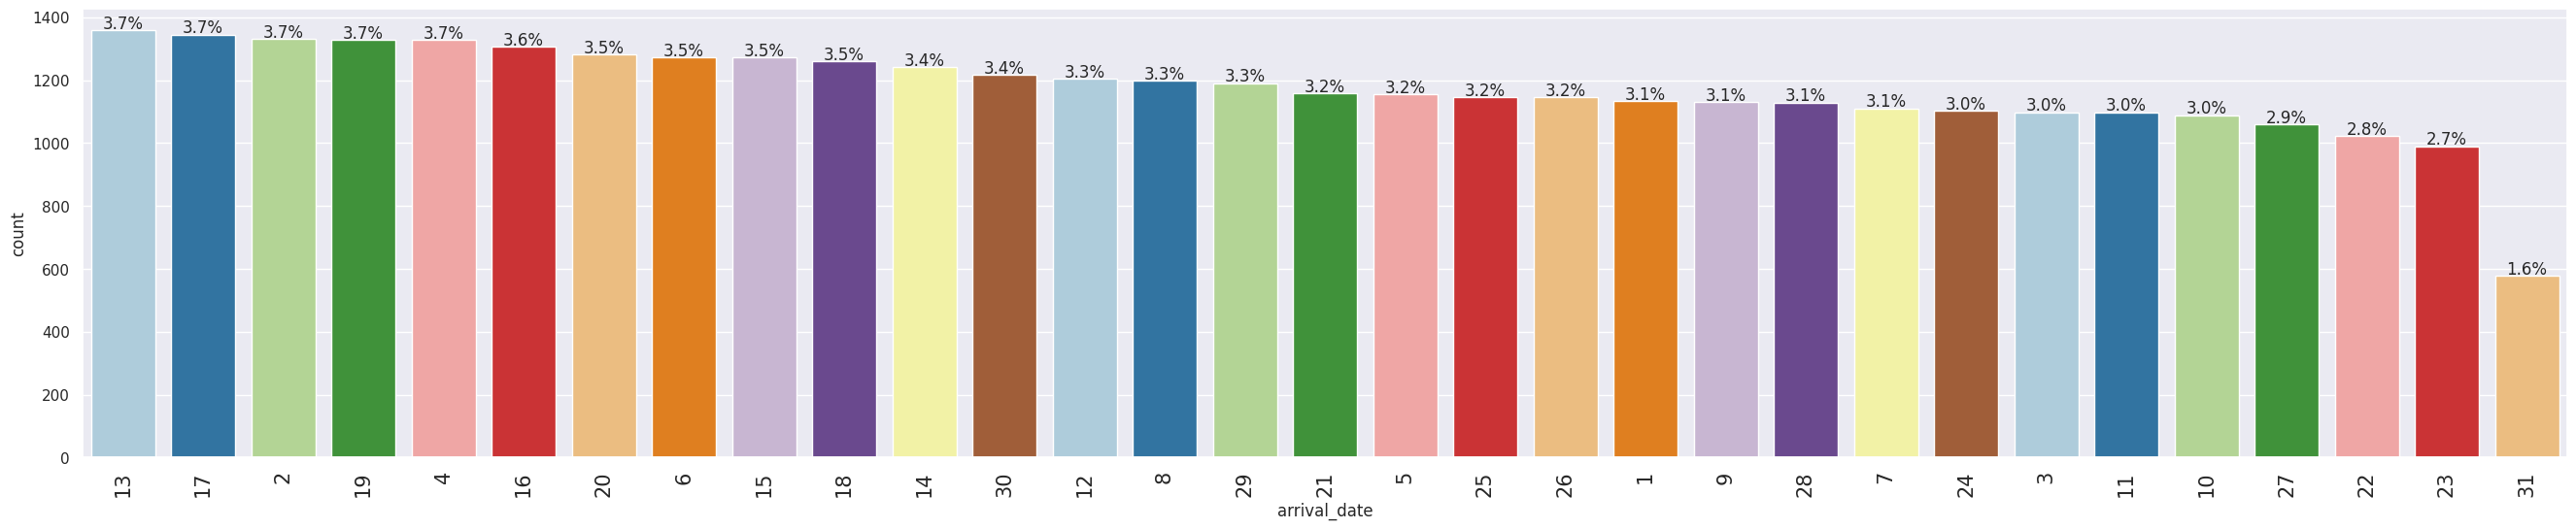

In [ ]:
# this code creates a labelled barplot of the distribution of the arrival date
labelled_barplot(df_copy, 'arrival_date', perc=True)

#### Market segment type


In [ ]:
# this code returns the frequency of unique values and percentages of the market segment type column
df_copy['market_segment_type'].value_counts(normalize=True)

,proportion
market_segment_type,
Online,0.640
Offline,0.290
Corporate,0.056
Complementary,0.011
Aviation,0.003


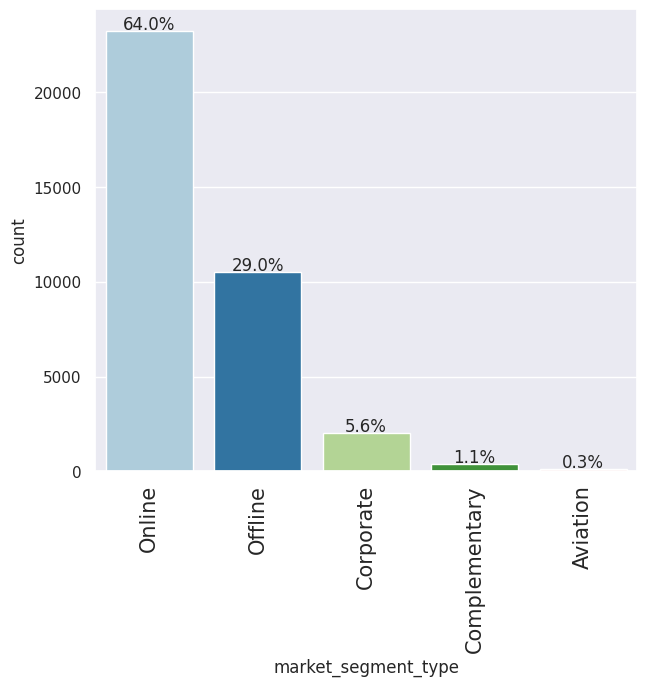

In [ ]:
# this code creates a labelled barplot of the distribution of the market segment
labelled_barplot(df_copy, 'market_segment_type', perc=True)

#### Repeated guest

In [ ]:
# this code returns the frequency of unique values and percentages of the repeated guest column
df_copy['repeated_guest'].value_counts(normalize=True)

,proportion
repeated_guest,
0,0.974
1,0.026


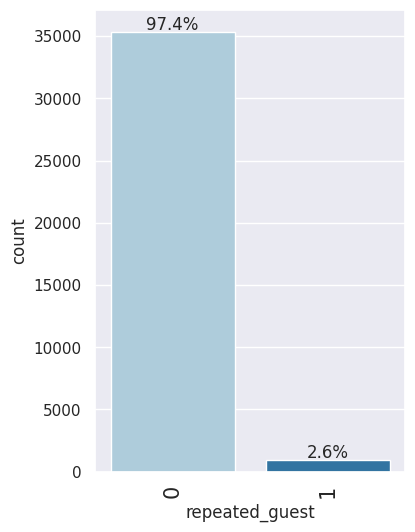

In [ ]:
# this code creates a labelled barplot of the distribution of the repeated guest
labelled_barplot(df_copy, 'repeated_guest', perc=True)

#### Number of previous cancellations


In [ ]:
# this code returns the frequency of unique values and percentages of the number of previous cancellations column
df_copy['no_of_previous_cancellations'].value_counts(normalize=True)

,proportion
no_of_previous_cancellations,
0,0.991
1,0.005
2,0.001
3,0.001
11,0.001
5,0.000
4,0.000
13,0.000
6,0.000


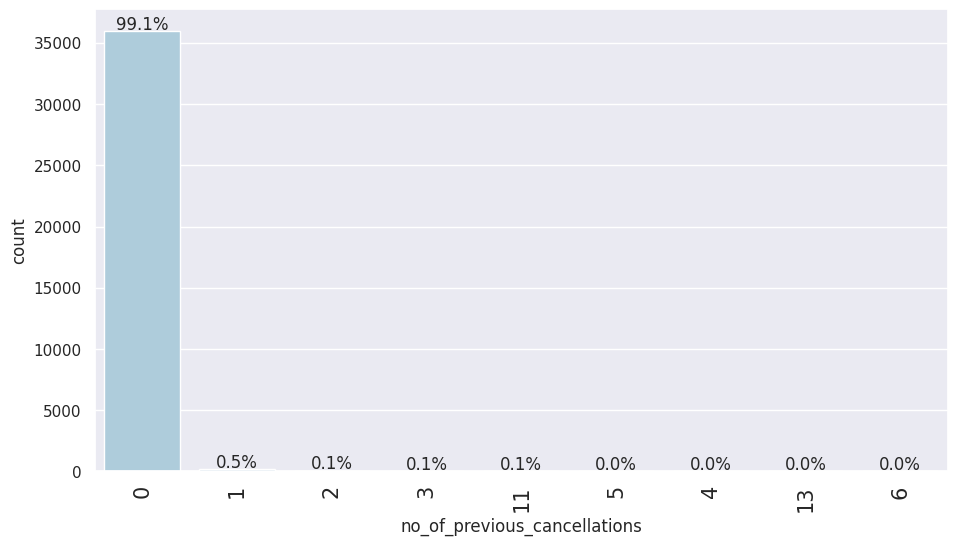

In [ ]:
# this code creates a labelled barplot of the distribution of the number of previous cancellations
labelled_barplot(df_copy, 'no_of_previous_cancellations', perc=True)

#### Number of previous bookings not canceled


In [ ]:
# this code returns the frequency of unique values and percentages of the number of previous bookings not cancelled
df_copy['no_of_previous_bookings_not_canceled'].value_counts(normalize=True)

,proportion
no_of_previous_bookings_not_canceled,
0,0.978
1,0.006
2,0.003
3,0.002
4,0.002
5,0.002
6,0.001
7,0.001
8,0.001


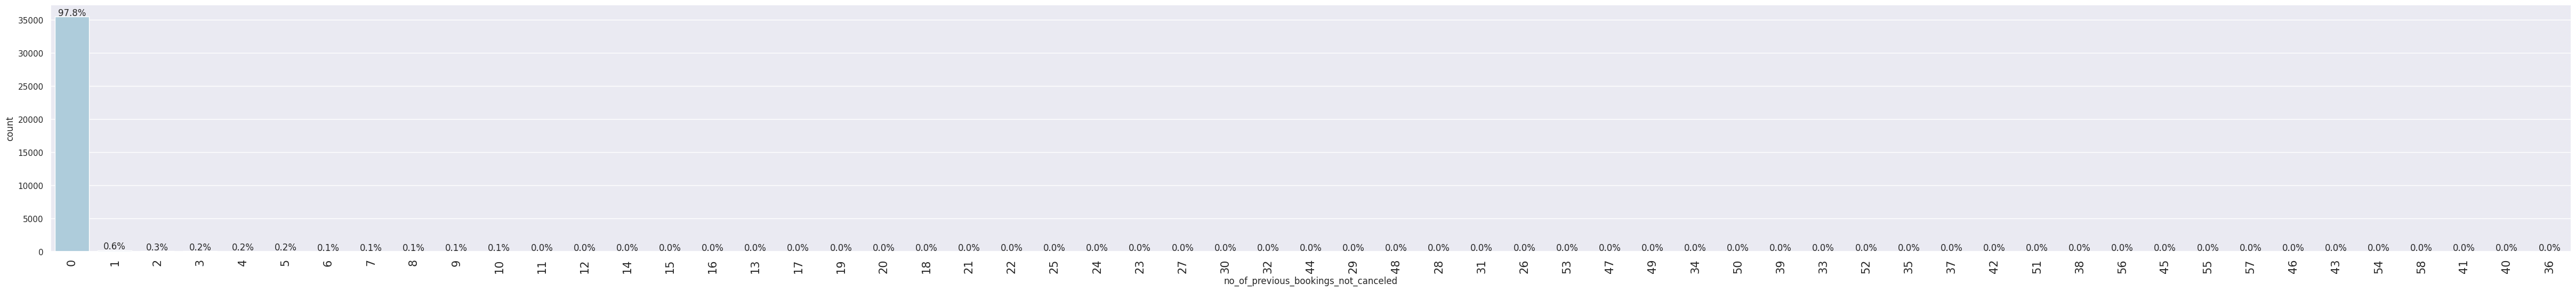

In [ ]:
# this code creates a labelled barplot of the number of previous bookings not cancelled
labelled_barplot(df_copy, 'no_of_previous_bookings_not_canceled', perc=True)

#### Average price per room


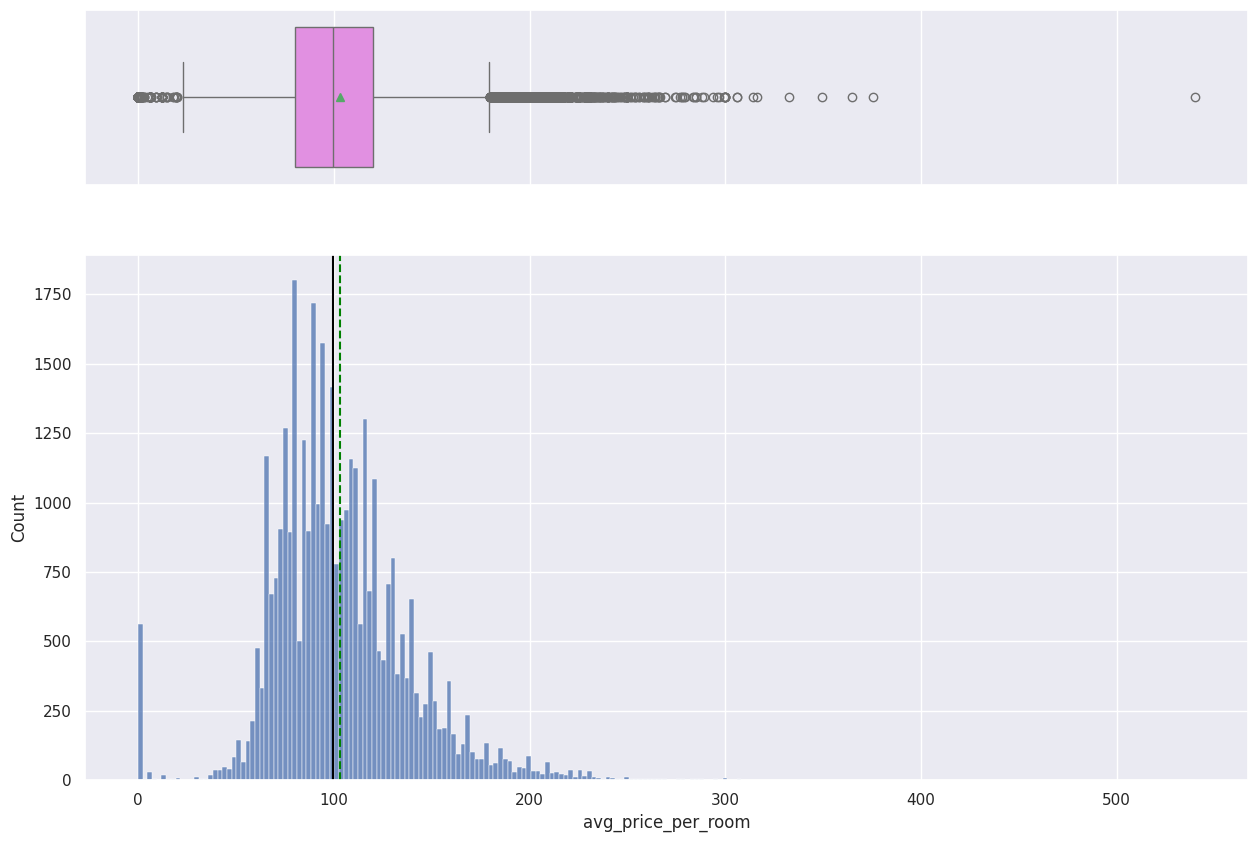

In [ ]:
# this code creates a histogram and boxplot of the distribution of the average price per room
histogram_boxplot(df_copy, 'avg_price_per_room')

Mean, standard deviation, mininum and maximun values, 25%, 50%, 75%, COUNT

#### Number of special requests


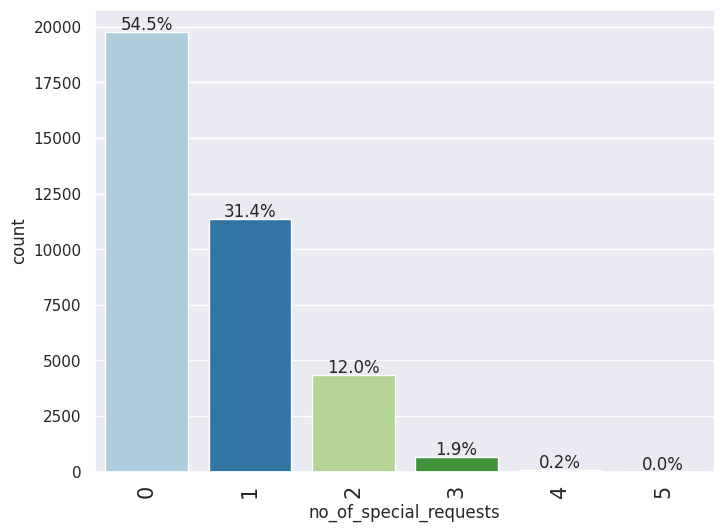

In [ ]:
# this code creates a labelled barplot of the distribution of the number of special requests
labelled_barplot(df_copy, 'no_of_special_requests', perc=True)

#### Booking status

In [ ]:
# this code returns the frequency of unique values and percentages of the booking status column
df_copy['booking_status'].value_counts(normalize=True)

,proportion
booking_status,
Not_Canceled,0.672
Canceled,0.328


In [ ]:
# this code converts not canceled to 0 and canceled to 1
df_copy['booking_status'] = df_copy['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

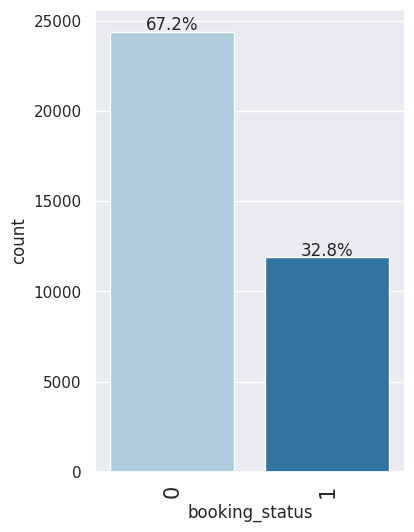

In [ ]:
# this code creates a labelled barplot of the distribution of the booking status
labelled_barplot(df_copy, 'booking_status', perc=True)

### Bivariate Analysis

#### Correlation of all variables

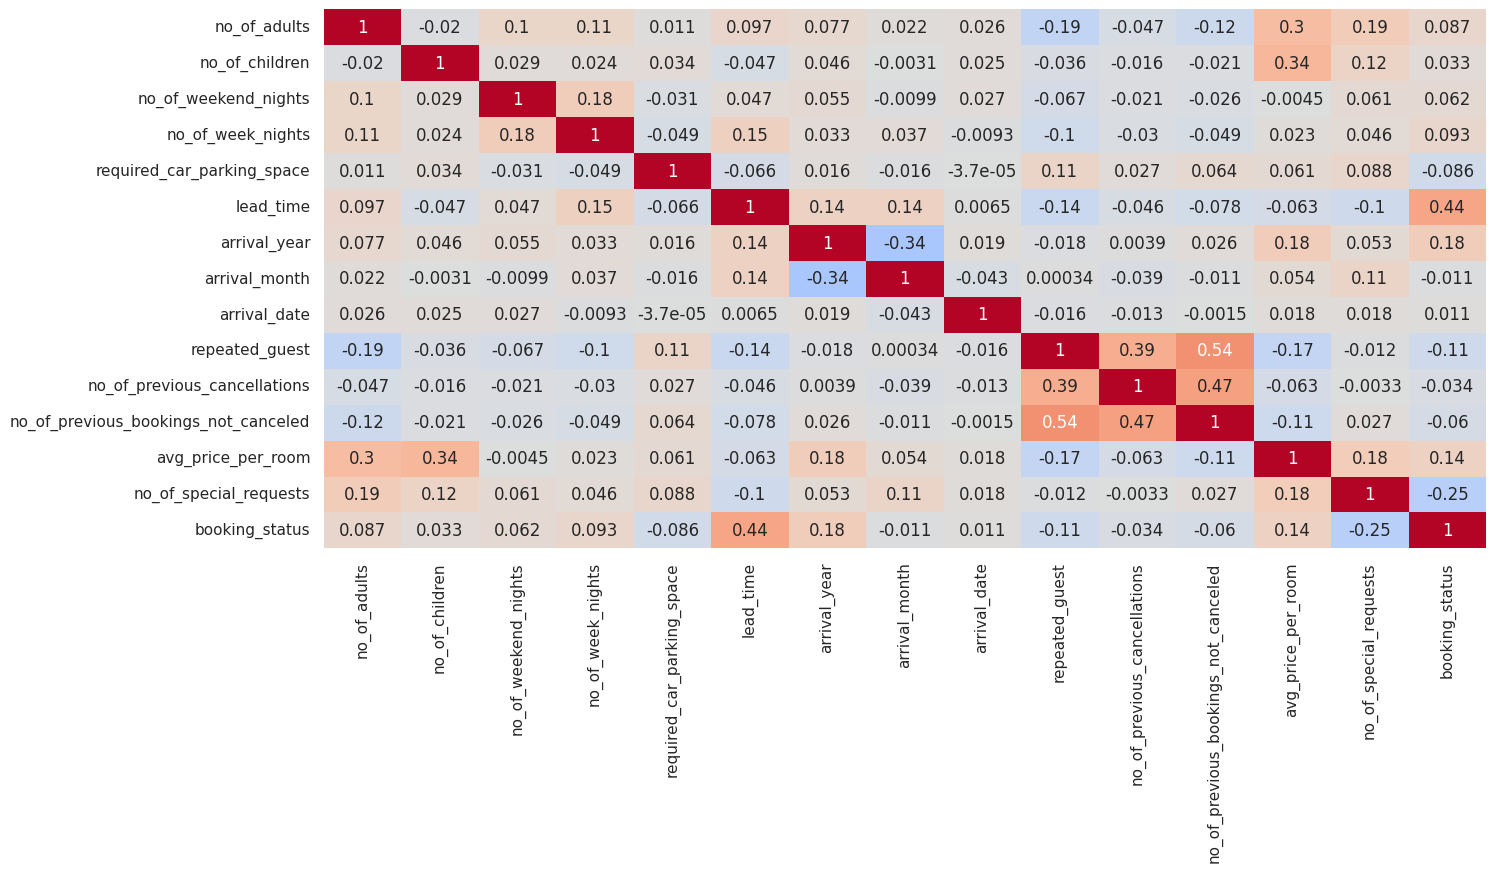

In [ ]:
# this code creates a plot with a size 15,7 and a heatmap of the dataframe df_copy
plt.figure(figsize=(15, 7))

# select only numeric columns for correlation
numeric_df = df_copy.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.show()

#### Busiest months in the hotel

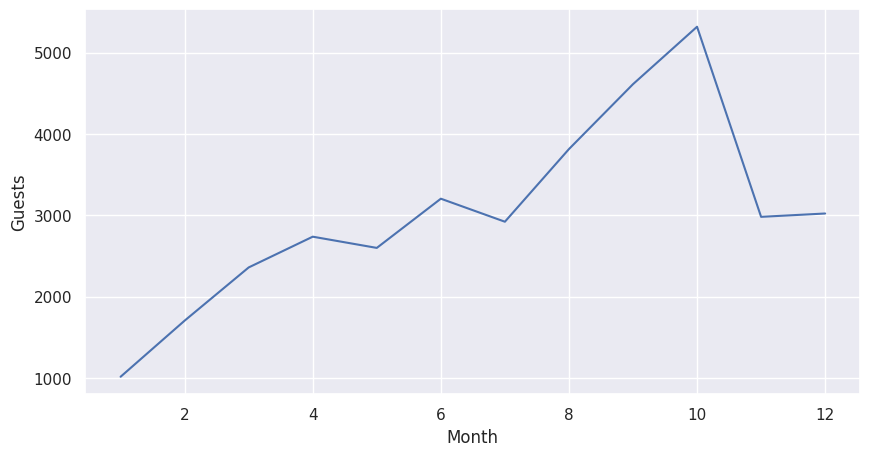

In [ ]:
# grouping the data on arrival months and extracting the count of bookings
monthly_data = df_copy.groupby(["arrival_month"])["booking_status"].count()

# creating a dataframe with months and count of customers in each month
monthly_data = pd.DataFrame(
    {"Month": list(monthly_data.index), "Guests": list(monthly_data.values)}
)

# plotting the trend over different months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x="Month", y="Guests")
plt.show()

#### Room price vs market segment

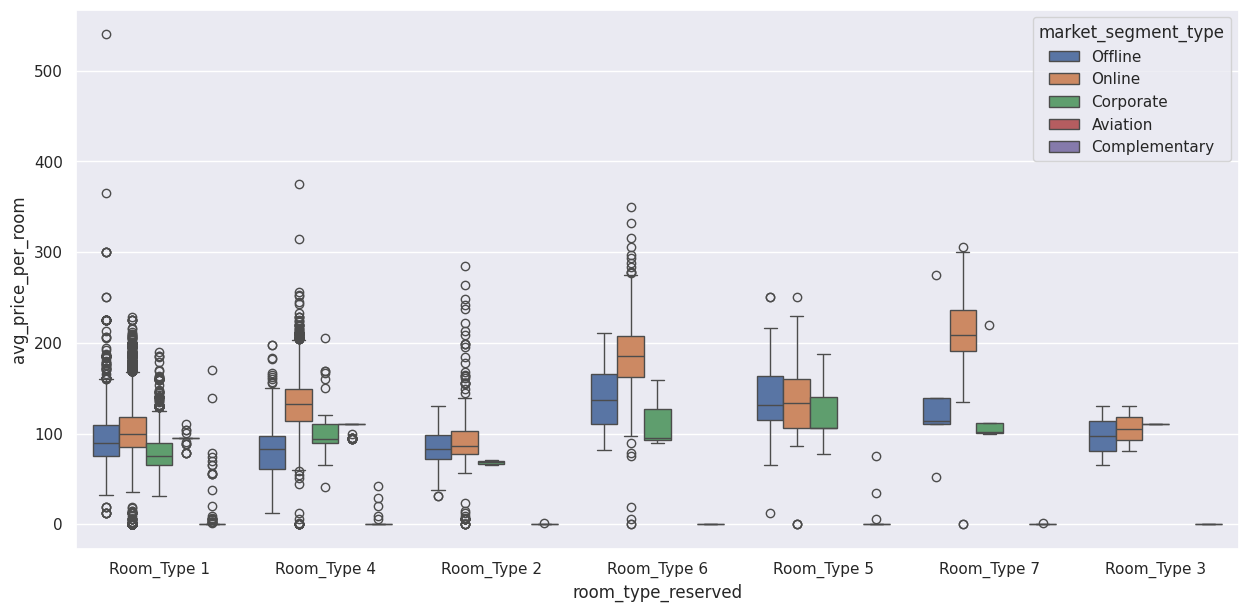

In [ ]:
# this code creates a plot to compare the differences in room prices in different market segments
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_copy, x='room_type_reserved', y='avg_price_per_room', hue='market_segment_type')
plt.show()

market_segment_type  Aviation  Complementary  Corporate  Offline  Online  \
room_type_reserved                                                         
All                       125            391       2017    10528   23214   
Room_Type 4                65             52         99      613    5228   
Room_Type 1                60            247       1833     9747   16243   
Room_Type 2                 0             20          2       57     613   
Room_Type 3                 0              2          1        2       2   
Room_Type 5                 0             17         74       81      93   
Room_Type 6                 0             14          3       23     926   
Room_Type 7                 0             39          5        5     109   

market_segment_type    All  
room_type_reserved          
All                  36275  
Room_Type 4           6057  
Room_Type 1          28130  
Room_Type 2            692  
Room_Type 3              7  
Room_Type 5            265  
Room_Ty

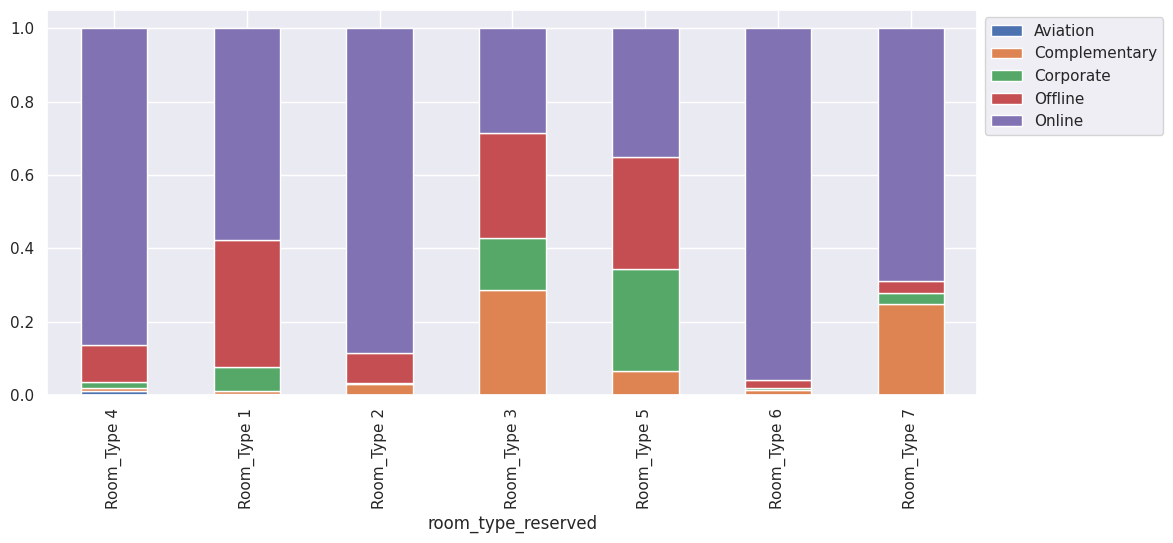

In [ ]:
# this code creates a stacked barplot to compare the differences in room prices in different market segments
stacked_barplot(df_copy, 'room_type_reserved', 'market_segment_type')

#### Repeated guest and booking status

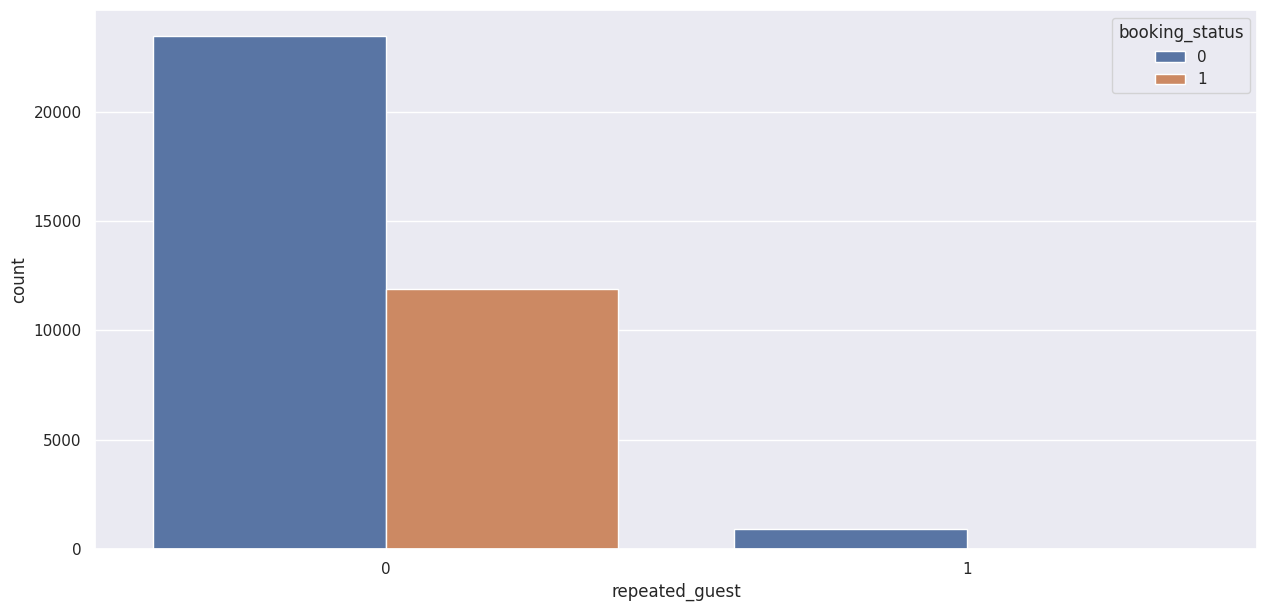

In [ ]:
# this code creates a plot to determine the percentage of repeating guests that cancel
plt.figure(figsize=(15, 7))
sns.countplot(data=df_copy, x='repeated_guest', hue='booking_status')
plt.show()

booking_status      0      1    All
repeated_guest                     
All             24390  11885  36275
0               23476  11869  35345
1                 914     16    930
------------------------------------------------------------------------------------------------------------------------


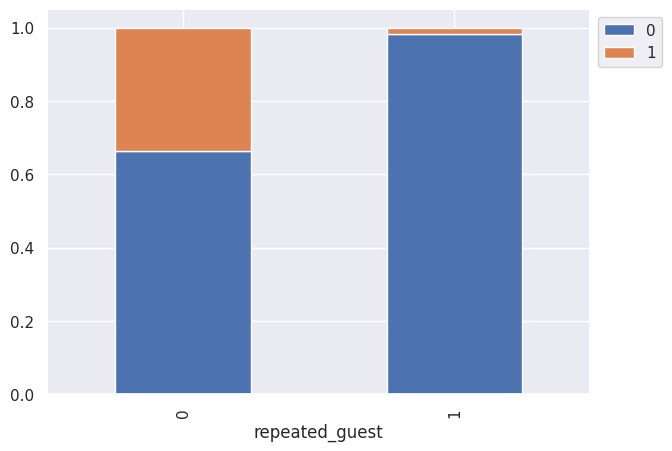

In [ ]:
# this code creates a stacked barplot of the repeated guests and booking status
stacked_barplot(df_copy, 'repeated_guest', 'booking_status')

#### Number of special requests and booking status

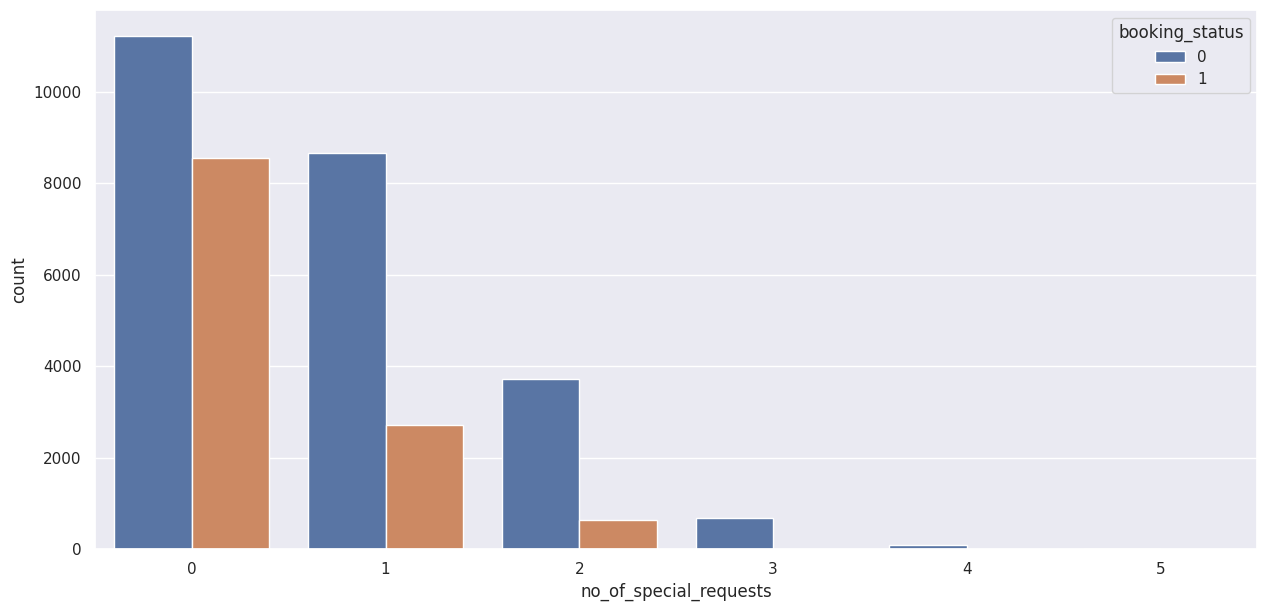

In [ ]:
# this code creates a plot to determine the number of guests who have special requirements when booking a hotel room
plt.figure(figsize=(15, 7))
sns.countplot(data=df_copy, x='no_of_special_requests', hue='booking_status')
plt.show()

booking_status              0      1    All
no_of_special_requests                     
All                     24390  11885  36275
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
------------------------------------------------------------------------------------------------------------------------


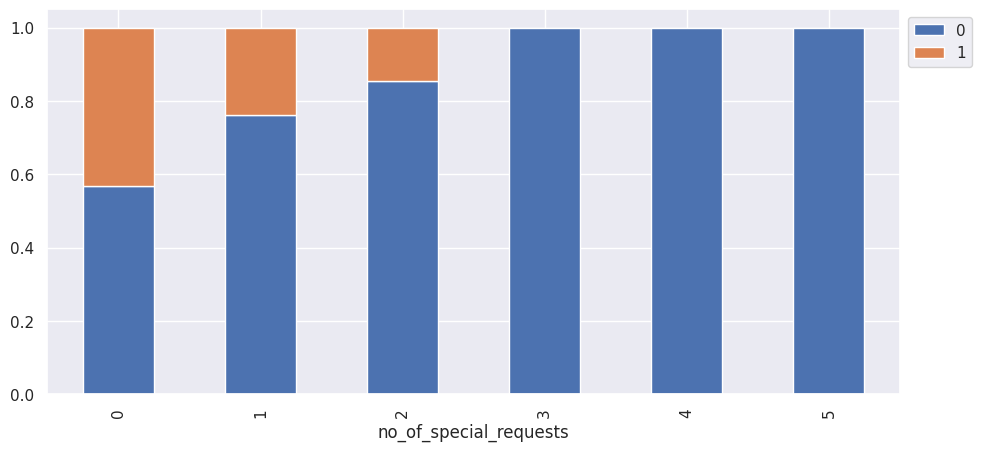

In [ ]:
# this code creates a stacked barplot of the number of guests who have special requirements when booking a hotel room
stacked_barplot(df_copy, 'no_of_special_requests', 'booking_status')

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Outlier detection

In [ ]:
# this code creates a list of numeric columns and assigns it to the variable 'numeric_columns'
numeric_columns = df_copy.select_dtypes(include=np.number).columns.tolist()

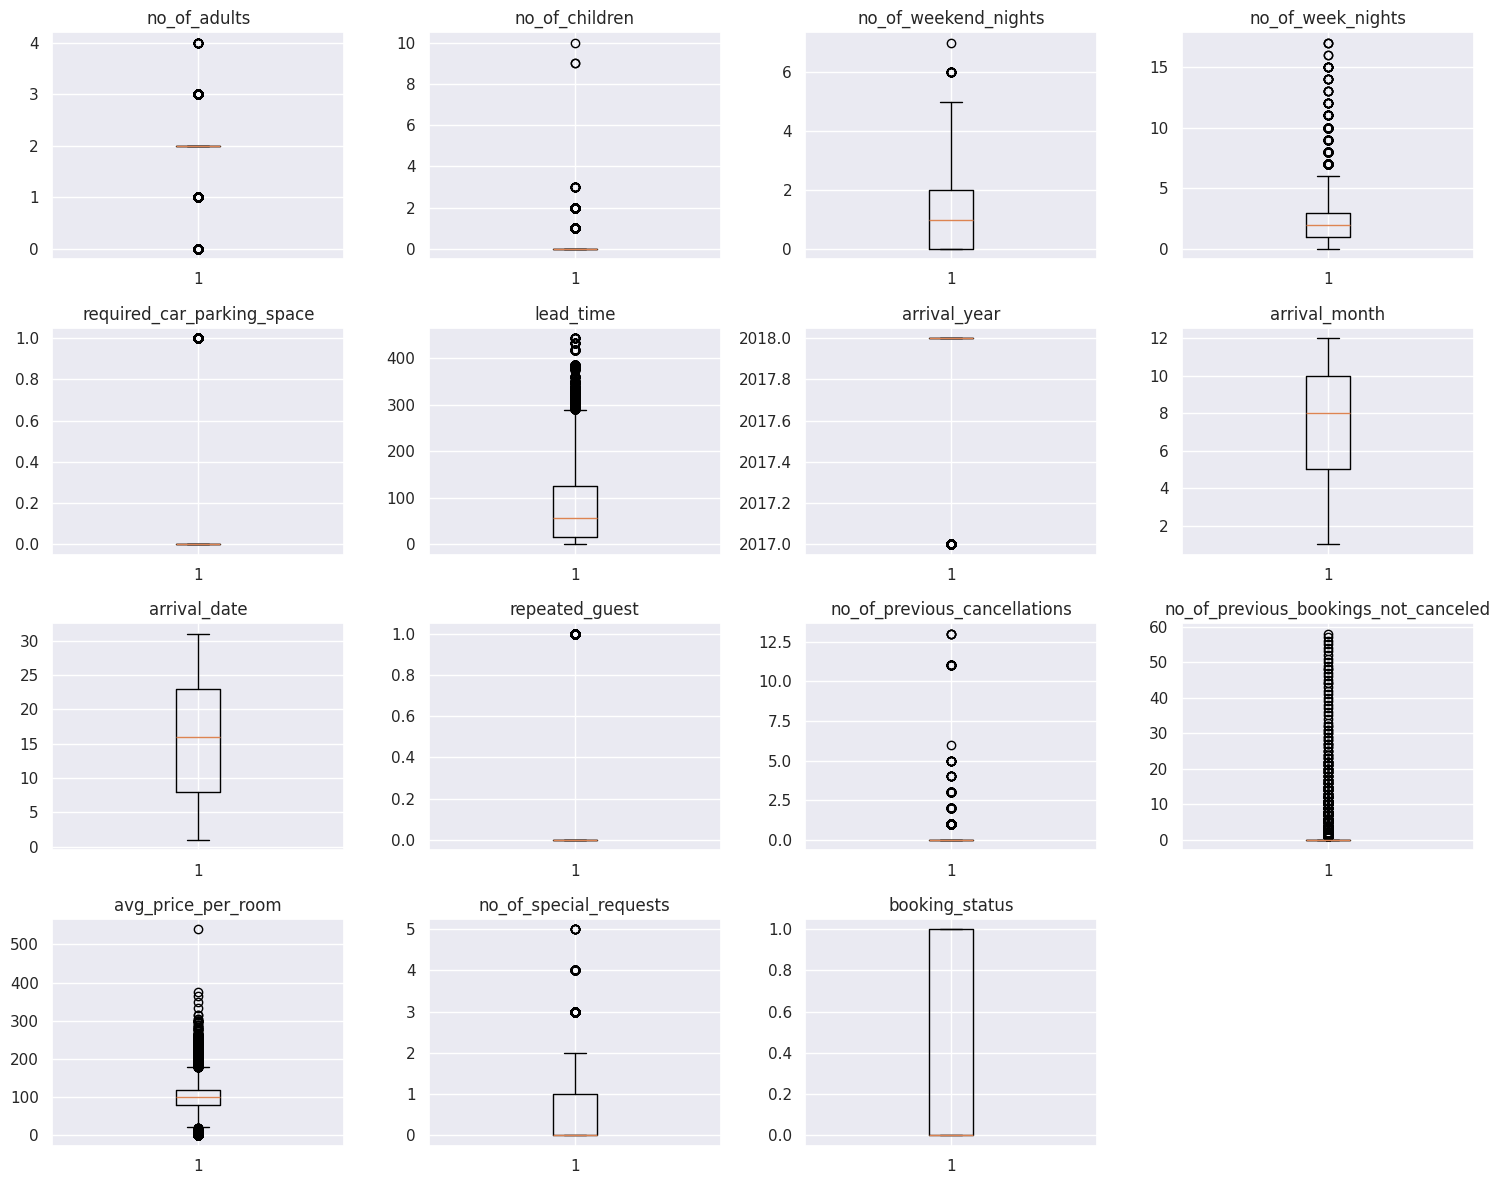

In [ ]:
# this code creates a figure with the size 15, 12
plt.figure(figsize=(15,12))

# this code is a loop that creates a boxplot of the numeric columns on the same scale
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i+1)
    plt.boxplot(df_copy[variable])
    plt.title(variable)
    plt.tight_layout()

plt.show()

### Data preparation for modeling

#### Defining functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0])

    return df_perf

In [ ]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Independent and dependent variables

In [ ]:
X = df_copy.drop(['booking_status', 'Booking_ID'], axis=1)
y = df_copy['booking_status']

print(X.head())
print()
print(y.head())

   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             2               0                     1                  2   
1             2               0                     2                  3   
2             1               0                     2                  1   
3             2               0                     0                  2   
4             2               0                     1                  1   

  type_of_meal_plan  required_car_parking_space room_type_reserved  lead_time  \
0       Meal Plan 1                           0        Room_Type 1        224   
1      Not Selected                           0        Room_Type 1          5   
2       Meal Plan 1                           0        Room_Type 1          1   
3       Meal Plan 1                           0        Room_Type 1        211   
4      Not Selected                           0        Room_Type 1         48   

   arrival_year  arrival_month  arrival_date market_segm

In [ ]:
# this code adds the intercept to data
X = sm.add_constant(X)

In [ ]:
# this code creates dummy variables and assigns it to the variable 'X'
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True).astype(float)

In [ ]:
# this code splits the data in a 70:30 ratio for training to test the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])
print()
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print()
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Number of rows in train data = 25392
Number of rows in test data = 10883

Percentage of classes in training set:
booking_status
0   0.671
1   0.329
Name: proportion, dtype: float64

Percentage of classes in test set:
booking_status
0   0.676
1   0.324
Name: proportion, dtype: float64


## Building a Logistic Regression model

In [ ]:
# this code fits the logistic regression model
log_reg = sm.Logit(y_train, X_train.astype(float)).fit(display=False)
print(log_reg.summary())

         Current function value: 0.425036
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25364
Method:                           MLE   Df Model:                           27
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                  0.3293
Time:                        19:27:03   Log-Likelihood:                -10793.
converged:                      False   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 -924.5923    120.817     -7.653      0.000   -1161.390

In [ ]:
# this code checks the performance of the logistic regression model
print("Training performance model 1:")
model_performance_classification_statsmodels(log_reg, X_train, y_train)

Training performance model 1:


,Accuracy,Recall,Precision,F1
0,0.806,0.634,0.740,0.683


### Test for multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
# this code defines a function to check VIF
def calculate_vif(predictors):
    """
    Function to calculate VIF
    """
    vif = pd.DataFrame()
    vif["variables"] = predictors.columns
    vif["VIF"] = [variance_inflation_factor(predictors.values, i) for i in range(len(predictors.columns))]
    return vif


In [ ]:
# this code checks the vif values
calculate_vif(X_train)

,variables,VIF
0,const,39468156.706
1,no_of_adults,1.348
2,no_of_children,1.978
3,no_of_weekend_nights,1.069
4,no_of_week_nights,1.096
5,required_car_parking_space,1.040
6,lead_time,1.395
7,arrival_year,1.431
8,arrival_month,1.276
9,arrival_date,1.007


### Dropping variables with high p-value

In [ ]:
# this code returns the initial list of columns
cols = X_train.columns.tolist()

# this code sets the the maximum p-value to 1
max_p_value = 1

# this code defines and fits the model
while len(cols) >= 0:
  model = sm.Logit(y_train, X_train[cols]).fit(display=False)

# this code sets the p-values and maximum p-value
  p_values = model.pvalues
  max_p_value = p_values.max()

# this code names the variable with the maximum p-value
  if max_p_value > 0.05:
    variable_with_max_p_value = p_values.idxmax()
    cols.remove(variable_with_max_p_value)
  else:
    break

# this code prints the final list of columns
selected_features = cols
print(selected_features)

         Current function value: 0.425036
         Iterations: 35
Optimization terminated successfully.
         Current function value: 0.425588
         Iterations 13
Optimization terminated successfully.
         Current function value: 0.425588
         Iterations 13
Optimization terminated successfully.
         Current function value: 0.425589
         Iterations 13
Optimization terminated successfully.
         Current function value: 0.425593
         Iterations 13
Optimization terminated successfully.
         Current function value: 0.425648
         Iterations 11
Optimization terminated successfully.
         Current function value: 0.425677
         Iterations 11
['const', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'repeated_guest', 'no_of_previous_cancellations', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_N

In [ ]:
# this code creates new training and testing datasets that contain the selected features
X_train1 = X_train[selected_features]
X_test1 = X_test[selected_features]

In [ ]:
# this code trains the logistic regression on X_train1, fits the model and prints the summary
log_reg1 = sm.Logit(y_train, X_train1.astype(float)).fit(display=False)
print(log_reg1.summary())

Optimization terminated successfully.
         Current function value: 0.425677
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                  0.3283
Time:                        19:27:11   Log-Likelihood:                -10809.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           -917.2860    120.456     -7.615    

### Model performance evaluation

In [ ]:
# this code checks the performance of the X_train1 and y_train
print("Training performance model 2:")
model_performance_classification_statsmodels(log_reg1, X_train1, y_train)

Training performance model 2:


,Accuracy,Recall,Precision,F1
0,0.805,0.633,0.739,0.682


### Converting coefficients to odds

In [ ]:
# this code converts coefficients to odds
odds = np.exp(log_reg1.params)

# this code calculates the percentage change
odds_perc_change = (odds - 1) * 100

# this code adds odds to a dataframe
pd.DataFrame({"Odds": odds, "Odds_change%": odds_perc_change}, index=X_train1.columns).T

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Offline
Odds,0.000,1.115,1.164,1.115,1.043,0.203,1.016,1.573,0.959,0.065,1.257,1.019,0.230,1.180,1.331,0.700,0.754,0.479,0.381,0.239,0.453,0.168
Odds_change%,-100.000,11.475,16.436,11.475,4.264,-79.695,1.584,57.324,-4.147,-93.520,25.716,1.935,-77.006,17.992,33.089,-29.954,-24.617,-52.060,-61.901,-76.097,-54.742,-83.250


### Checking performance of the training model

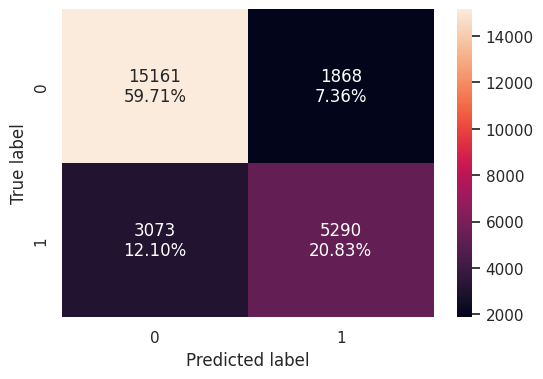

In [ ]:
# this code creates the confusion matrix
confusion_matrix_statsmodels(log_reg1, X_train1, y_train)

In [ ]:
# this code checks the performance of the X_train1 and y_train and assigns it to a variable
print("Training performance model:")
logreg_model_train_perf = model_performance_classification_statsmodels(log_reg1, X_train1, y_train)

Training performance model:


## Model performance improvement

### ROC-AUC training set

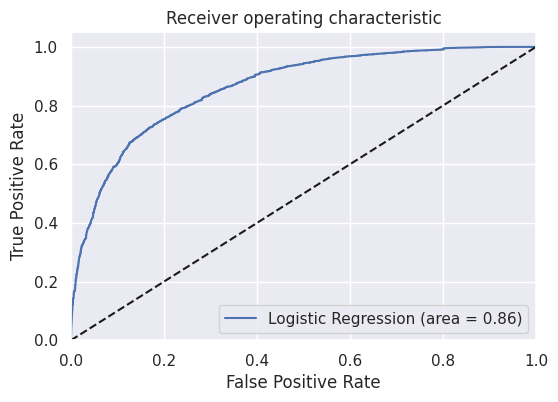

In [ ]:
# this code displays the roc-auc curve on the training model
log_reg_roc_auc_train = roc_auc_score(y_train, log_reg1.predict(X_train1))
fpr, tpr, thresholds = roc_curve(y_train, log_reg1.predict(X_train1))
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % log_reg_roc_auc_train)
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# this code creates the optimal threshold using the ROC-AUC curve
fpr, tpr, thresholds = roc_curve(y_train, log_reg1.predict(X_train1))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print("Optimal threshold:", optimal_threshold_auc_roc)

Optimal threshold: 0.3710466623488775


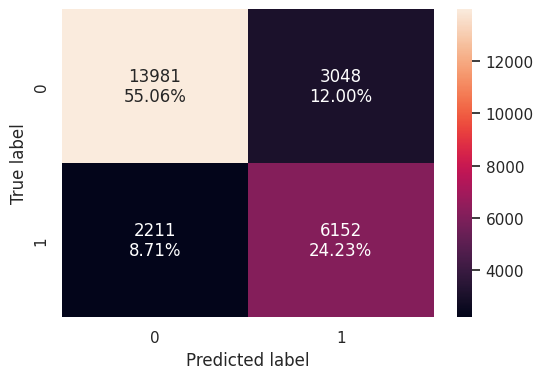

In [ ]:
# this code creates the confusion matrix with the optimal threshold
confusion_matrix_statsmodels(log_reg1, X_train1, y_train, optimal_threshold_auc_roc)

In [ ]:
# this code checks the perfomance of the model
print("Training performance model:")
logreg_model_train_perf_threshold = model_performance_classification_statsmodels(log_reg1, X_train1, y_train, optimal_threshold_auc_roc)

Training performance model:


### Using the precision-recall curve

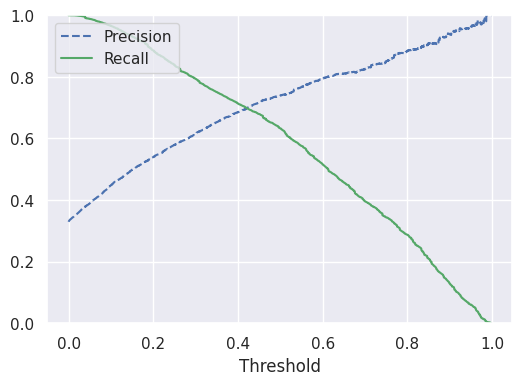

In [ ]:
# this code uses the precision-recall curve to find a better threshold
precision, recall, thresholds = precision_recall_curve(y_train, log_reg1.predict(X_train1))

def plot_precision_recall_vs_threshold(precision, recall, thresholds):
    plt.plot(thresholds, precision[:-1], "b--", label="Precision")
    plt.plot(thresholds, recall[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

plt.figure(figsize=(6, 4))
plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.show()

In [ ]:
# this code sets the variable optimal_thresehold_recall_precision to 0.42
optimal_threshold_recall_precision = 0.42

### Checking perfomance of the training model

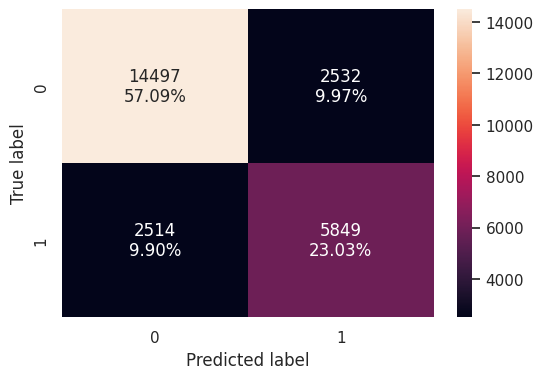

In [ ]:
# this code creates the confusion matrix with the optimal_thresehold_recall_precision
confusion_matrix_statsmodels(log_reg1, X_train1, y_train, optimal_threshold_recall_precision)

In [ ]:
# this code checks the perfomance of the model
print("Training performance model:")
logreg_model_train_perf_threshold_recall_precision = model_performance_classification_statsmodels(log_reg1, X_train1, y_train, optimal_threshold_recall_precision)

Training performance model:


### Test Model

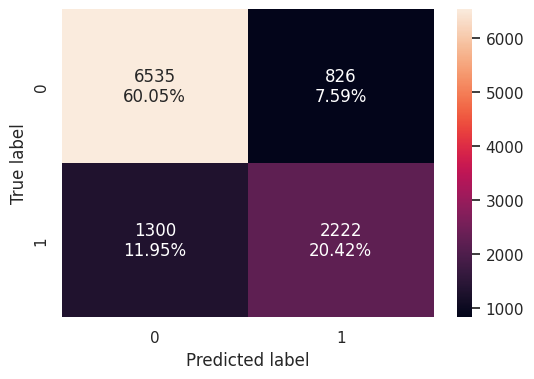

In [ ]:
# this code creates the confusion matrix of the test model
confusion_matrix_statsmodels(log_reg1, X_test1, y_test)

In [ ]:
# this code checks the performance of the test model
print("Test performance model:")
logreg_model_test_perf = model_performance_classification_statsmodels(log_reg1, X_test1, y_test)

Test performance model:


### ROC-AUC test set

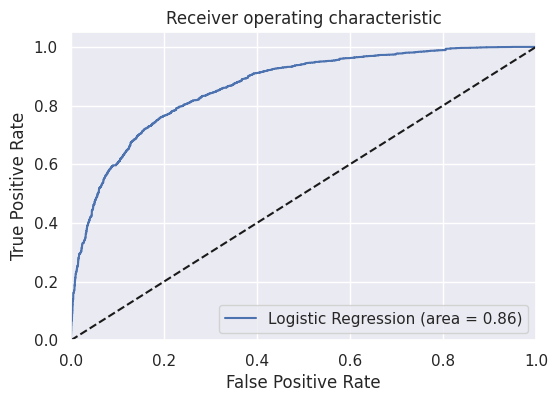

In [ ]:
# this code displays the roc-auc curve on the test model
log_reg_roc_auc_test = roc_auc_score(y_test, log_reg1.predict(X_test1))
fpr, tpr, thresholds = roc_curve(y_test, log_reg1.predict(X_test1))
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % log_reg_roc_auc_test)
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

Optimal threshold = 0.37

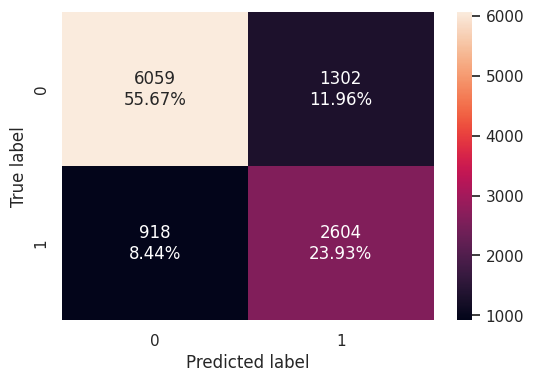

In [ ]:
# this code creates the confusion matrix of the test set with the optimal_threshold_auc_roc as threshold
confusion_matrix_statsmodels(log_reg1, X_test1, y_test, optimal_threshold_auc_roc)

In [ ]:
# this code checks the performance of the model with the optimal_threshold_auc_roc
print("Test performance model:")
logreg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(log_reg1, X_test1, y_test, optimal_threshold_auc_roc)

Test performance model:


Optimal threshold = 0.42

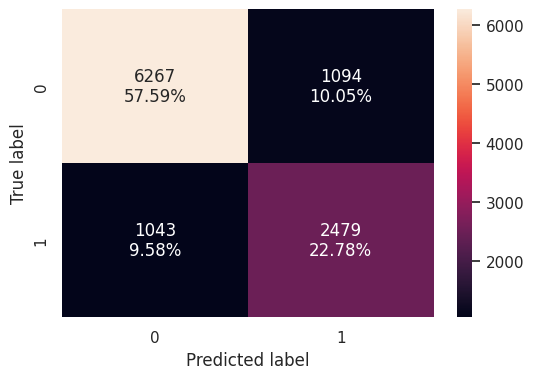

In [ ]:
# this code creates the confusion matric with the optimal_threshold_recall_precision
confusion_matrix_statsmodels(log_reg1, X_test1, y_test, optimal_threshold_recall_precision)

In [ ]:
# this checks the perfomrnace of the model with the optimal_threshold_recall_precision
print("Test performance model:")
logreg_model_test_perf_threshold_recall_precision = model_performance_classification_statsmodels(log_reg1, X_test1, y_test, optimal_threshold_recall_precision)

Test performance model:


## Final Model Summary

In [ ]:
# this code compares the performance of the training model to the logistic regression models
print("Comparison of training performance:")
models_train_compare_df = pd.concat([logreg_model_train_perf.T,
                                     logreg_model_train_perf_threshold.T,
                                     logreg_model_train_perf_threshold_recall_precision.T],
                                    axis=1)

models_train_compare_df.columns = ["Logistic Regresion-Default Threshold",
                                   "Logistic Regresion-0.37 Threshold",
                                   "Logistic Regresion-0.42 Threshold"]

models_train_compare_df

Comparison of training performance:


,Logistic Regresion-Default Threshold,Logistic Regresion-0.37 Threshold,Logistic Regresion-0.42 Threshold
Accuracy,0.805,0.793,0.801
Recall,0.633,0.736,0.699
Precision,0.739,0.669,0.698
F1,0.682,0.701,0.699


In [ ]:
# this code compares the performance of the test model to the logistic regression models
print("Comparison of test performance:")
models_test_compare_df = pd.concat([logreg_model_test_perf.T,
                                    logreg_model_test_perf_threshold_auc_roc.T,
                                    logreg_model_test_perf_threshold_recall_precision.T],
                                   axis=1)

models_test_compare_df.columns = ["Logistic Regresion-Default Threshold",
                                  "Logistic Regresion-0.37 Threshold",
                                  "Logistic Regresion-0.42 Threshold"]

models_test_compare_df

Comparison of test performance:


,Logistic Regresion-Default Threshold,Logistic Regresion-0.37 Threshold,Logistic Regresion-0.42 Threshold
Accuracy,0.805,0.796,0.804
Recall,0.631,0.739,0.704
Precision,0.729,0.667,0.694
F1,0.676,0.701,0.699


## Building a Decision Tree model

#### Data Preparation for the Decision Tree

In [ ]:
# this code creates the independent and dependent variables for the decision tree
X = df_copy.drop(["booking_status"], axis=1)
Y = df_copy["booking_status"]

# this code creates dummies variables for X
X = pd.get_dummies(X, drop_first=True)

# this code splits the data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1)

In [ ]:
print("Shape of Training set:", X_train.shape)
print("Shape of test set:", X_test.shape)
print("Percentage of classes in training set:", y_train.value_counts(normalize=True))
print("Percentage of classes in test set:", y_test.value_counts(normalize=True))

Shape of Training set: (25392, 36301)
Shape of test set: (10883, 36301)
Percentage of classes in training set: booking_status
0   0.671
1   0.329
Name: proportion, dtype: float64
Percentage of classes in test set: booking_status
0   0.676
1   0.324
Name: proportion, dtype: float64


#### First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The model_performance_classification_sklearn function will be used to check the model performance of models.
* The confusion_matrix_sklearnfunction will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Building Decision Tree Model

In [ ]:
# this code fits the decision tree on the train data
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Checking model performance on training set

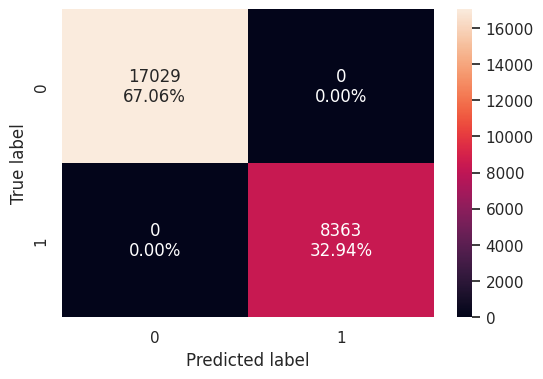

In [ ]:
# this code creates the confusion matrix for train data
confusion_matrix_sklearn(model, X_train, y_train)

In [ ]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train)
print("Training performance model:")
decision_tree_perf_train

Training performance model:


,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


#### Checking model performance on test set

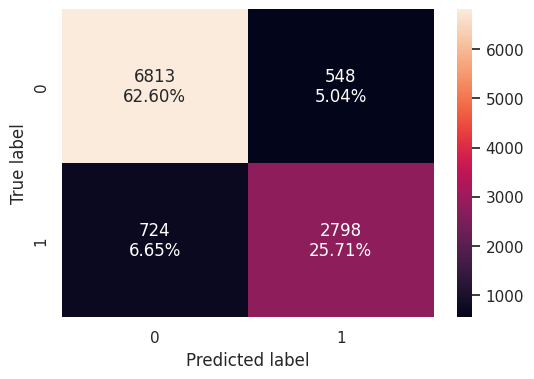

In [ ]:
# this code creates the confusion matrix for test data
confusion_matrix_sklearn(model, X_test, y_test)

In [ ]:
# this code checks the performance of the test set
decision_tree_perf_test = model_performance_classification_sklearn(model, X_test, y_test)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.883,0.794,0.836,0.815


**Before pruning the tree let's check the important features.**

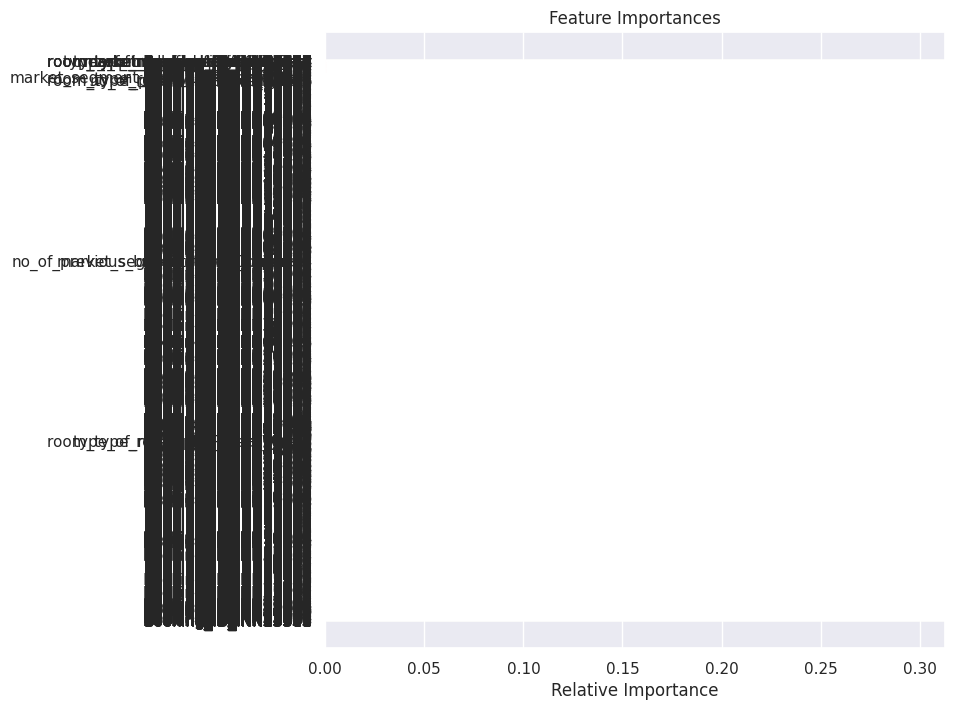

In [ ]:
feature_names = list(X_train.columns)
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="pink", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Pruning the tree

**Pre-Pruning**

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Grid of parameters to choose from
parameters = {
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

#### Checking performance on training set

In [ ]:
confusion_matrix_sklearn(estimator, X_train, y_train) ## Complete the code to create confusion matrix for train data

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(estimator, X_train, y_train) ## Complete the code to check performance on train set
decision_tree_tune_perf_train

#### Checking performance on test set

In [ ]:
confusion_matrix_sklearn(estimator, X_test, y_test) ## Complete the code to create confusion matrix for test data

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(estimator, X_test, y_test) ## Complete the code to check performance on test set
decision_tree_tune_perf_test

#### Visualizing the Decision Tree

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

In [ ]:
# importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Cost Complexity Pruning**

In [ ]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [ ]:
pd.DataFrame(path)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced")
    clf.fit(X_train, y_train) ## Complete the code to fit decision tree on training data
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]))

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#### F1 Score vs alpha for training and testing sets

In [ ]:
f1_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = f1_score(y_train, pred_train)
    f1_train.append(values_train)

f1_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = f1_score(y_test, pred_test)
    f1_test.append(values_test)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs alpha for training and testing sets")
ax.plot(ccp_alphas, f1_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, f1_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
index_best_model = np.argmax(f1_test)
best_model = clfs[index_best_model]
print(best_model)

#### Checking performance on training set

In [ ]:
confusion_matrix_sklearn(best_model, X_train, y_train)

In [ ]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train)
decision_tree_post_perf_train

#### Checking performance on test set

In [ ]:
confusion_matrix_sklearn(best_model, X_test, y_test) ## Complete the code to create confusion matrix for test data on best model

In [ ]:
decision_tree_post_test = model_performance_classification_sklearn(
    best_model, X_train, y_train) ## Complete the code to check performance of test set on best model
decision_tree_post_test

In [ ]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Comparing Decision Tree models

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T],
    axis=1)
models_train_comp_df.columns = [
    "Decision Tree sklearn",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)"]
print("Comparison of training performance:")
models_train_comp_df

In [ ]:
# testing performance comparison
models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_perf_test.T],
    axis=1)
models_test_comp_df.columns = [
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)"]
print("Comparison of test performance:")
models_train_comp_df